<a href="https://colab.research.google.com/github/nicholas-schwier-class/Computational-Probability-and-Stats-2026/blob/main/Ch8_B_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Medical Testing
Conceptual idea

A test is not perfect. Even if someone tests positive, it does not automatically mean they have the disease.

Bayesian inference helps us answer:

If a test is positive, what is the probability the person actually has the disease?

Given information

Disease rate in the population = 2%
Test sensitivity (detects disease when present) = 95%
Test specificity (correctly detects no disease) = 90%

We want:

P(Disease | Positive test)

In [2]:
# Prior probability of disease
P_disease = 0.02

# Probability test is positive if the person HAS the disease
P_pos_given_disease = 0.95

# Probability test is positive if the person does NOT have the disease
P_pos_given_no_disease = 1 - 0.90   # false positive rate

# Probability of not having the disease
P_no_disease = 1 - P_disease

# Total probability of testing positive
P_positive = (P_pos_given_disease * P_disease) + \
             (P_pos_given_no_disease * P_no_disease)

# Bayes' theorem
P_disease_given_positive = (P_pos_given_disease * P_disease) / P_positive

print("Probability of disease given a positive test =", P_disease_given_positive)

Probability of disease given a positive test = 0.16239316239316243


Email Spam Detection
Conceptual idea

Suppose we want to classify whether an email is spam based on whether it contains the word "free".

We want:

P(Spam | word = "free")

Given information

40% of emails are spam

80% of spam emails contain the word "free"

10% of non-spam emails contain the word "free"

In [5]:
# Prior probabilities
P_spam = 0.40
P_not_spam = 1 - P_spam

# Likelihoods
P_free_given_spam = 0.80
P_free_given_not_spam = 0.10

# Total probability that the word "free" appears
P_free = (P_free_given_spam * P_spam) + \
         (P_free_given_not_spam * P_not_spam)

# Bayes' theorem
P_spam_given_free = (P_free_given_spam * P_spam) / P_free

print("Probability the email is spam if it contains 'free' =", P_spam_given_free)

Probability the email is spam if it contains 'free' = 0.8421052631578948


Updating Probability After New Data (Coin Example)
Conceptual idea

We are not sure whether a coin is fair.
We observe flips and update our belief using Bayesian thinking.



A company claims a product has a 50% success rate.
We test it 10 times and observe 8 successes.

We want to update the probability that the success rate is actually high.

In [4]:
import numpy as np

# Try many possible probabilities between 0 and 1
probabilities = np.linspace(0, 1, 1000)

# Observed data: 8 successes out of 10
successes = 8
trials = 10

# Likelihood for each probability
likelihood = (probabilities ** successes) * ((1 - probabilities) ** (trials - successes))

# Normalize so it becomes a probability distribution
posterior = likelihood / np.sum(likelihood)

# Find the most likely probability
best_probability = probabilities[np.argmax(posterior)]

print("Most likely success rate =", best_probability)

Most likely success rate = 0.7997997997997998


Business Example (Customer Purchase Prediction)
Conceptual idea

A company wants to know:

If a customer clicked an ad, what is the probability they will buy the product?

Given information

30% of customers buy a product

70% do not buy

60% of buyers clicked the ad

20% of non-buyers clicked the ad

In [3]:
# Prior probabilities
P_buy = 0.30
P_not_buy = 1 - P_buy

# Likelihoods
P_click_given_buy = 0.60
P_click_given_not_buy = 0.20

# Total probability of a click
P_click = (P_click_given_buy * P_buy) + \
          (P_click_given_not_buy * P_not_buy)

# Bayes theorem
P_buy_given_click = (P_click_given_buy * P_buy) / P_click

print("Probability a customer buys if they clicked the ad =", P_buy_given_click)

Probability a customer buys if they clicked the ad = 0.5625000000000001


Bayesian Machine Learning Model (Naive Bayes for Email Classification)
1. Conceptual overview

In machine learning, Bayesian inference is often used to classify observations into categories.

The model learns from data and answers:

Given the words in an email, what is the probability the email is spam?

This is Bayesian because the model uses:

Prior probability of spam
Probability of words given spam
Bayes theorem to compute the final probability

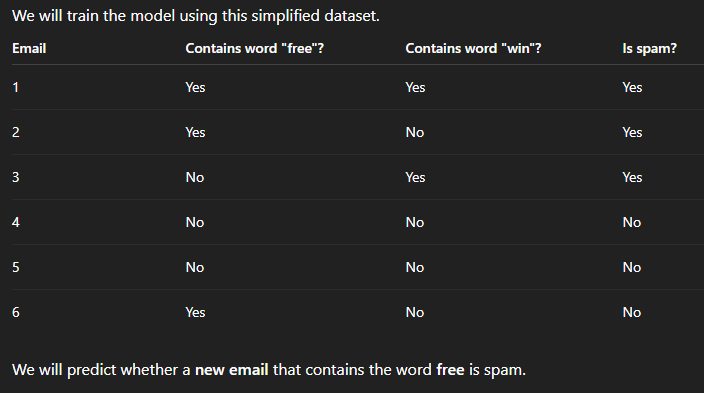


In [ ]:
# Training data
free = [1, 1, 0, 0, 0, 1]     # 1 = word appears
win  = [1, 0, 1, 0, 0, 0]
spam = [1, 1, 1, 0, 0, 0]     # 1 = spam

n = len(spam)

# Step 1: Prior probability of spam
P_spam = sum(spam) / n
P_not_spam = 1 - P_spam

# Step 2: Likelihoods
# P(free | spam)
free_spam = [free[i] for i in range(n) if spam[i] == 1]
P_free_given_spam = sum(free_spam) / len(free_spam)

# P(free | not spam)
free_not_spam = [free[i] for i in range(n) if spam[i] == 0]
P_free_given_not_spam = sum(free_not_spam) / len(free_not_spam)

# Step 3: Bayesian prediction
P_free = (P_free_given_spam * P_spam) + \
         (P_free_given_not_spam * P_not_spam)

P_spam_given_free = (P_free_given_spam * P_spam) / P_free

print("Probability email is spam if it contains 'free' =", P_spam_given_free)